## EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load cleaned data
df = pd.read_csv('../Data/chicago_crime_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Updated On'] = pd.to_datetime(df['Updated On'])

print(f"✓ Data loaded: {len(df):,} records")
print(f"✓ Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

✓ Data loaded: 496,290 records
✓ Date range: 2023-04-09 to 2025-03-15


In [4]:
# Overall crime type distribution
crime_counts = df['Primary Type'].value_counts()
crime_pct = (crime_counts / len(df) * 100).round(2)

print("="*70)
print("CRIME TYPE DISTRIBUTION")
print("="*70)
print(f"Total Crime Types: {df['Primary Type'].nunique()}\n")

crime_summary = pd.DataFrame({
    'Crime Type': crime_counts.index,
    'Count': crime_counts.values,
    'Percentage': crime_pct.values
})

print(crime_summary.to_string(index=False))

CRIME TYPE DISTRIBUTION
Total Crime Types: 31

                       Crime Type  Count  Percentage
                            THEFT 113837       22.94
                          BATTERY  86813       17.49
                  CRIMINAL DAMAGE  55257       11.13
              MOTOR VEHICLE THEFT  45845        9.24
                          ASSAULT  44272        8.92
                    OTHER OFFENSE  31881        6.42
               DECEPTIVE PRACTICE  31168        6.28
                          ROBBERY  18849        3.80
                         BURGLARY  15340        3.09
                WEAPONS VIOLATION  15283        3.08
                        NARCOTICS  11481        2.31
                CRIMINAL TRESPASS   9316        1.88
       OFFENSE INVOLVING CHILDREN   3132        0.63
          CRIMINAL SEXUAL ASSAULT   3092        0.62
                      SEX OFFENSE   2469        0.50
           PUBLIC PEACE VIOLATION   1825        0.37
 INTERFERENCE WITH PUBLIC OFFICER   1307        0.26

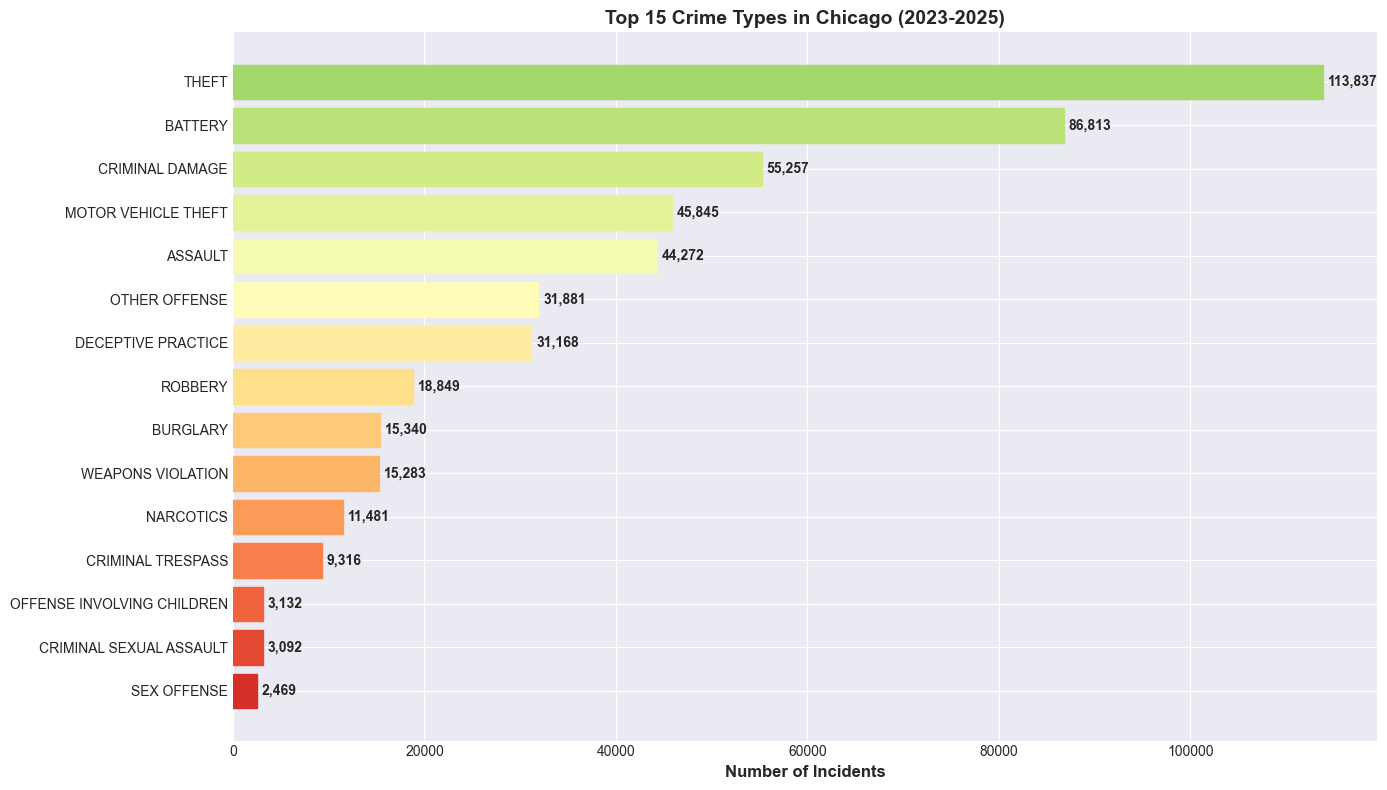


✓ Top crime: THEFT (113,837 incidents)


In [5]:
# Visualize top 15 crime types
fig, ax = plt.subplots(figsize=(14, 8))

top15_crimes = crime_counts.head(15)
bars = ax.barh(range(len(top15_crimes)), top15_crimes.values)

# Color gradient
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(top15_crimes)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.set_yticks(range(len(top15_crimes)))
ax.set_yticklabels(top15_crimes.index)
ax.set_xlabel('Number of Incidents', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Crime Types in Chicago (2023-2025)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(top15_crimes.values):
    ax.text(v + 500, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Top crime: {top15_crimes.index[0]} ({top15_crimes.values[0]:,} incidents)")

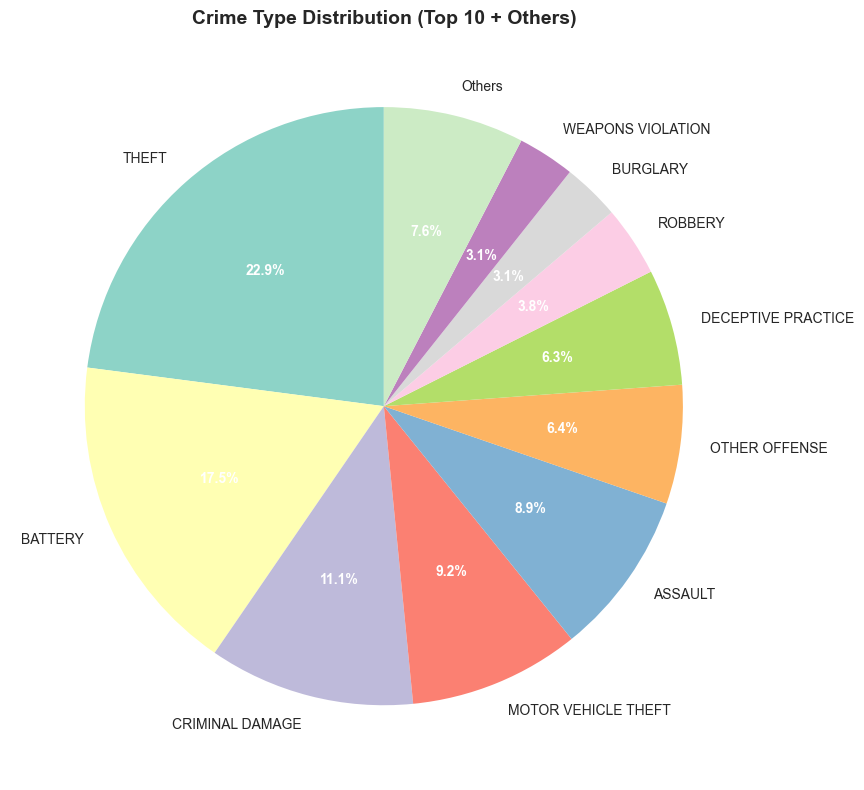

In [6]:
# Pie chart for top 10 crimes
fig, ax = plt.subplots(figsize=(12, 8))

top10 = crime_counts.head(10)
others = crime_counts.iloc[10:].sum()

pie_data = pd.concat([top10, pd.Series({'Others': others})])

colors = plt.cm.Set3(range(len(pie_data)))
wedges, texts, autotexts = ax.pie(pie_data.values, 
                                    labels=pie_data.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors,
                                    textprops={'fontsize': 10})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Crime Type Distribution (Top 10 + Others)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Crimes by year
yearly_crimes = df['Year'].value_counts().sort_index()

print("="*70)
print("YEARLY CRIME TRENDS")
print("="*70)
for year, count in yearly_crimes.items():
    print(f"  {year}: {count:,} crimes")

# Calculate year-over-year change
if len(yearly_crimes) > 1:
    for i in range(1, len(yearly_crimes)):
        prev_year = yearly_crimes.index[i-1]
        curr_year = yearly_crimes.index[i]
        change = ((yearly_crimes.iloc[i] - yearly_crimes.iloc[i-1]) / yearly_crimes.iloc[i-1] * 100)
        print(f"\n  {prev_year} → {curr_year}: {change:+.2f}% change")

YEARLY CRIME TRENDS
  2023: 195,363 crimes
  2024: 257,526 crimes
  2025: 43,401 crimes

  2023 → 2024: +31.82% change

  2024 → 2025: -83.15% change


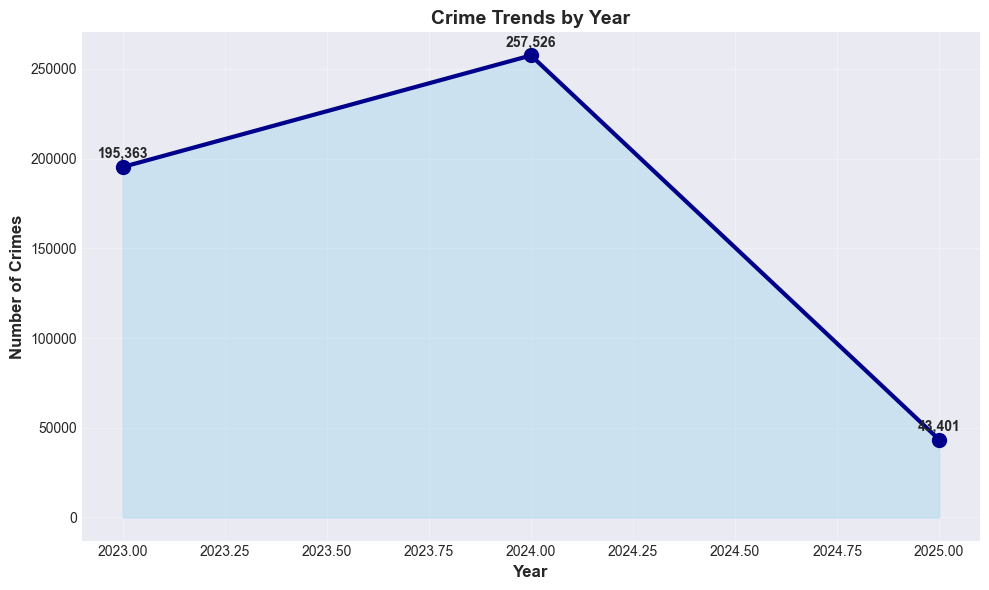

In [8]:
# Visualize yearly trend
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_crimes.index, yearly_crimes.values, marker='o', linewidth=3, markersize=10, color='darkblue')
ax.fill_between(yearly_crimes.index, yearly_crimes.values, alpha=0.3, color='skyblue')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
ax.set_title('Crime Trends by Year', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add value labels
for year, count in yearly_crimes.items():
    ax.text(year, count + 5000, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
# Crimes by month
monthly_crimes = df['Month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("="*70)
print("MONTHLY CRIME PATTERNS")
print("="*70)
for month, count in monthly_crimes.items():
    print(f"  {month_names[month-1]:3s}: {count:6,} crimes ({count/len(df)*100:5.2f}%)")

print(f"\n  Peak month: {month_names[monthly_crimes.idxmax()-1]} ({monthly_crimes.max():,})")
print(f"  Lowest month: {month_names[monthly_crimes.idxmin()-1]} ({monthly_crimes.min():,})")

MONTHLY CRIME PATTERNS
  Jan: 37,953 crimes ( 7.65%)
  Feb: 36,382 crimes ( 7.33%)
  Mar: 29,300 crimes ( 5.90%)
  Apr: 35,227 crimes ( 7.10%)
  May: 44,359 crimes ( 8.94%)
  Jun: 45,769 crimes ( 9.22%)
  Jul: 48,005 crimes ( 9.67%)
  Aug: 47,078 crimes ( 9.49%)
  Sep: 45,520 crimes ( 9.17%)
  Oct: 45,469 crimes ( 9.16%)
  Nov: 41,070 crimes ( 8.28%)
  Dec: 40,158 crimes ( 8.09%)

  Peak month: Jul (48,005)
  Lowest month: Mar (29,300)


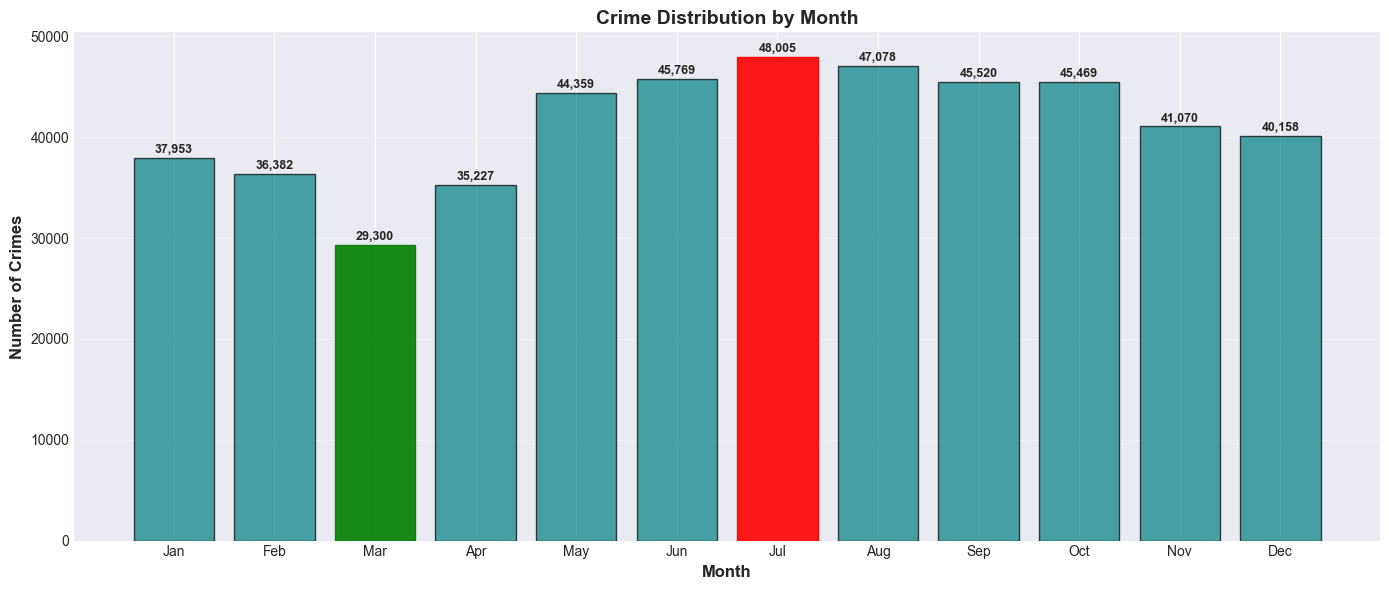

In [10]:
# Visualize monthly distribution
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(range(1, 13), monthly_crimes.values, color='teal', alpha=0.7, edgecolor='black')

# Highlight peak and lowest
bars[monthly_crimes.idxmax()-1].set_color('red')
bars[monthly_crimes.idxmax()-1].set_alpha(0.9)
bars[monthly_crimes.idxmin()-1].set_color('green')
bars[monthly_crimes.idxmin()-1].set_alpha(0.9)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
ax.set_title('Crime Distribution by Month', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(monthly_crimes.values, 1):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Crimes by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_crimes = df['DayName'].value_counts().reindex(day_order)

print("="*70)
print("DAY OF WEEK CRIME PATTERNS")
print("="*70)
for day, count in day_crimes.items():
    print(f"  {day:10s}: {count:6,} crimes ({count/len(df)*100:5.2f}%)")

print(f"\n  Peak day: {day_crimes.idxmax()} ({day_crimes.max():,})")
print(f"  Lowest day: {day_crimes.idxmin()} ({day_crimes.min():,})")

DAY OF WEEK CRIME PATTERNS
  Monday    : 71,351 crimes (14.38%)
  Tuesday   : 68,269 crimes (13.76%)
  Wednesday : 70,354 crimes (14.18%)
  Thursday  : 70,019 crimes (14.11%)
  Friday    : 72,848 crimes (14.68%)
  Saturday  : 72,216 crimes (14.55%)
  Sunday    : 71,233 crimes (14.35%)

  Peak day: Friday (72,848)
  Lowest day: Tuesday (68,269)


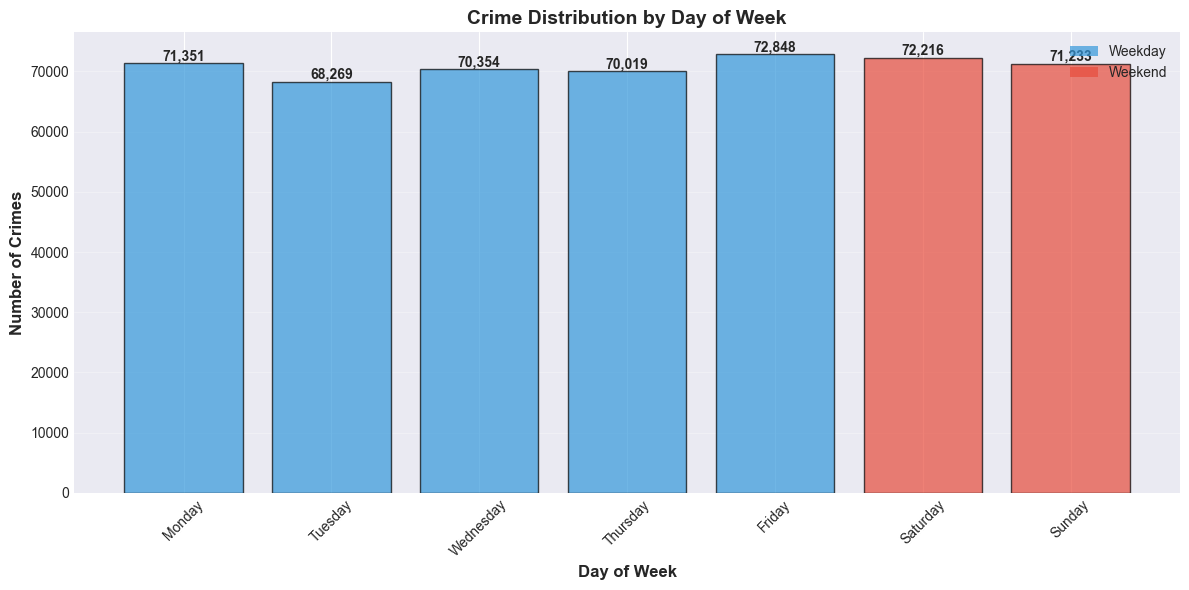

In [12]:
# Visualize day of week
fig, ax = plt.subplots(figsize=(12, 6))

colors_week = ['#3498db' if i < 5 else '#e74c3c' for i in range(7)]  # Blue for weekdays, Red for weekend
bars = ax.bar(day_order, day_crimes.values, color=colors_week, alpha=0.7, edgecolor='black')

ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
ax.set_title('Crime Distribution by Day of Week', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45)

# Add value labels
for i, v in enumerate(day_crimes.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', alpha=0.7, label='Weekday'),
                   Patch(facecolor='#e74c3c', alpha=0.7, label='Weekend')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [13]:
# Crimes by hour
hourly_crimes = df['Hour'].value_counts().sort_index()

print("="*70)
print("HOURLY CRIME PATTERNS")
print("="*70)
print("\nTop 5 Peak Hours:")
for hour, count in hourly_crimes.nlargest(5).items():
    print(f"  {hour:02d}:00 - {count:,} crimes")

print("\nTop 5 Quietest Hours:")
for hour, count in hourly_crimes.nsmallest(5).items():
    print(f"  {hour:02d}:00 - {count:,} crimes")

HOURLY CRIME PATTERNS

Top 5 Peak Hours:
  00:00 - 34,532 crimes
  12:00 - 28,070 crimes
  15:00 - 26,909 crimes
  17:00 - 26,803 crimes
  16:00 - 26,487 crimes

Top 5 Quietest Hours:
  05:00 - 9,174 crimes
  06:00 - 9,631 crimes
  04:00 - 10,543 crimes
  07:00 - 12,498 crimes
  03:00 - 12,899 crimes


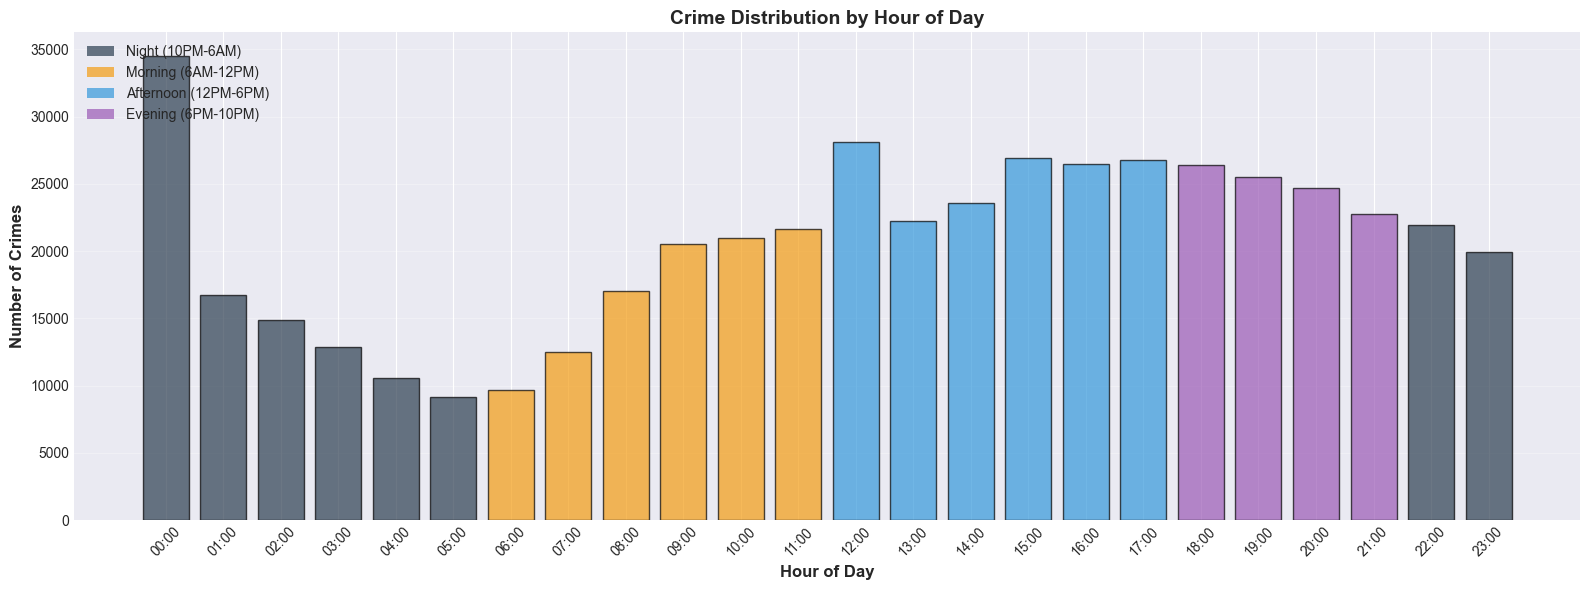

In [14]:
# Visualize hourly distribution
fig, ax = plt.subplots(figsize=(16, 6))

# Color by time of day
colors_hour = ['#2c3e50' if h < 6 or h >= 22 else 
               '#f39c12' if 6 <= h < 12 else 
               '#3498db' if 12 <= h < 18 else 
               '#9b59b6' for h in range(24)]

bars = ax.bar(range(24), hourly_crimes.values, color=colors_hour, alpha=0.7, edgecolor='black')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
ax.set_title('Crime Distribution by Hour of Day', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2c3e50', alpha=0.7, label='Night (10PM-6AM)'),
    Patch(facecolor='#f39c12', alpha=0.7, label='Morning (6AM-12PM)'),
    Patch(facecolor='#3498db', alpha=0.7, label='Afternoon (12PM-6PM)'),
    Patch(facecolor='#9b59b6', alpha=0.7, label='Evening (6PM-10PM)')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

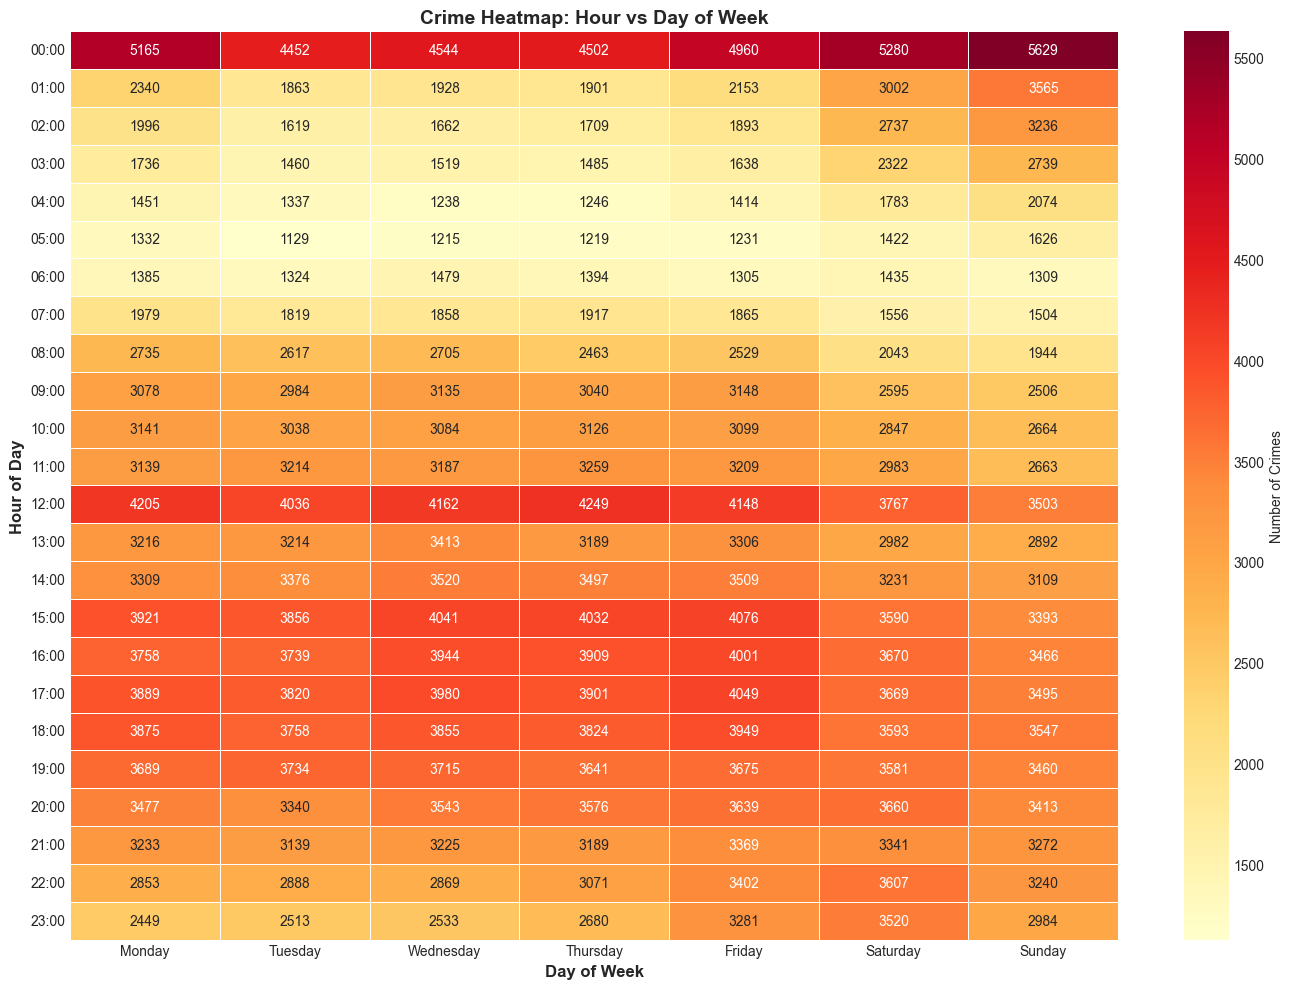


✓ Heatmap shows peak crime times across the week


In [15]:
# Create pivot table for heatmap
hour_day_pivot = df.groupby(['Hour', 'DayName']).size().unstack(fill_value=0)
hour_day_pivot = hour_day_pivot[day_order]  # Reorder columns

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(hour_day_pivot, cmap='YlOrRd', annot=True, fmt='d', 
            linewidths=0.5, cbar_kws={'label': 'Number of Crimes'},
            ax=ax)

ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_title('Crime Heatmap: Hour vs Day of Week', fontsize=14, fontweight='bold')
ax.set_yticklabels([f'{h:02d}:00' for h in range(24)], rotation=0)

plt.tight_layout()
plt.show()

print("\n✓ Heatmap shows peak crime times across the week")

In [16]:
# Crimes by district
district_crimes = df['District'].value_counts().sort_index()

print("="*70)
print("DISTRICT-WISE CRIME DISTRIBUTION")
print("="*70)
print(f"Total Districts: {df['District'].nunique()}\n")

print("Top 10 Districts by Crime Count:")
for district, count in district_crimes.nlargest(10).items():
    print(f"  District {district:2d}: {count:6,} crimes ({count/len(df)*100:5.2f}%)")

DISTRICT-WISE CRIME DISTRIBUTION
Total Districts: 23

Top 10 Districts by Crime Count:
  District  8: 32,654 crimes ( 6.58%)
  District 12: 30,322 crimes ( 6.11%)
  District  6: 28,902 crimes ( 5.82%)
  District  1: 28,060 crimes ( 5.65%)
  District  4: 27,025 crimes ( 5.45%)
  District 11: 26,838 crimes ( 5.41%)
  District 19: 26,834 crimes ( 5.41%)
  District 25: 25,966 crimes ( 5.23%)
  District 18: 25,574 crimes ( 5.15%)
  District  2: 25,543 crimes ( 5.15%)


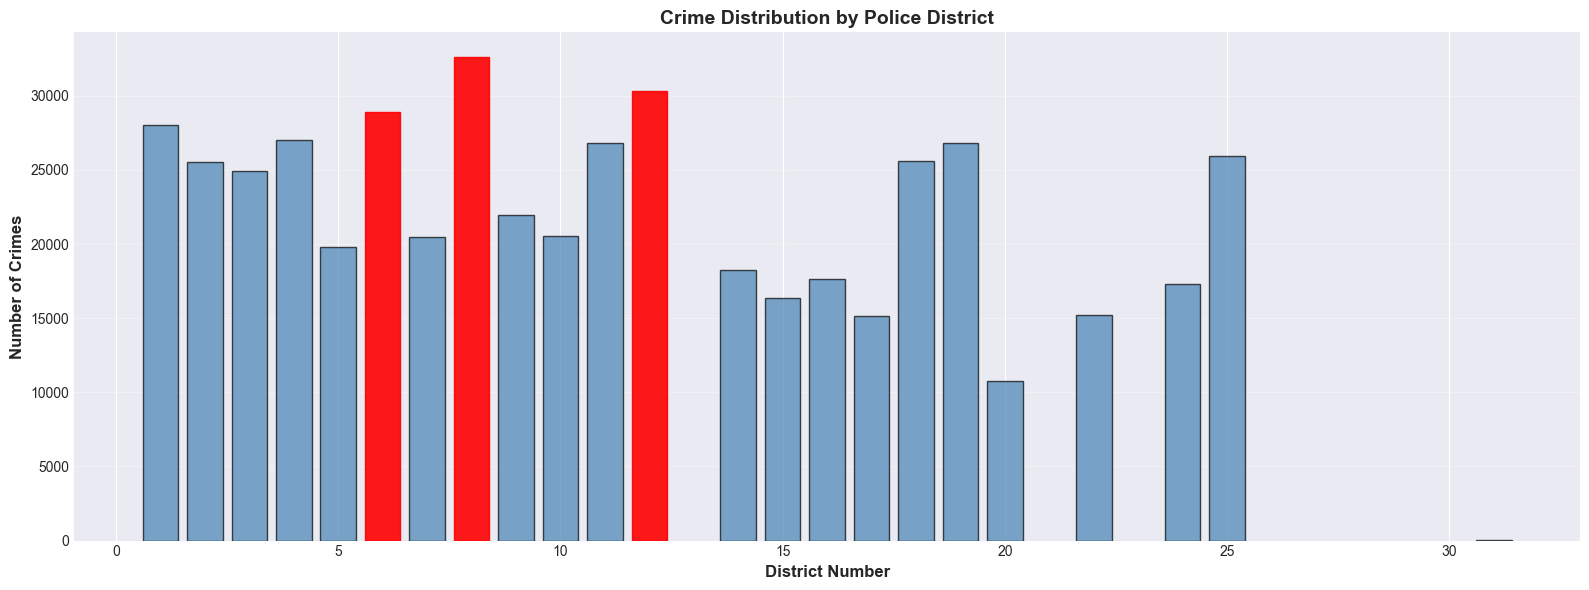

In [17]:
# Visualize district distribution
fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(district_crimes.index, district_crimes.values, color='steelblue', alpha=0.7, edgecolor='black')

# Highlight top 3 districts
top3_districts = district_crimes.nlargest(3).index
for i, bar in enumerate(bars):
    if district_crimes.index[i] in top3_districts:
        bar.set_color('red')
        bar.set_alpha(0.9)

ax.set_xlabel('District Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
ax.set_title('Crime Distribution by Police District', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Top locations where crimes occur
location_crimes = df['Location Description'].value_counts().head(15)

print("="*70)
print("TOP 15 CRIME LOCATIONS")
print("="*70)
for i, (loc, count) in enumerate(location_crimes.items(), 1):
    print(f"{i:2d}. {loc:35s} - {count:6,} ({count/len(df)*100:5.2f}%)")

TOP 15 CRIME LOCATIONS
 1. STREET                              - 138,286 (27.86%)
 2. APARTMENT                           - 94,336 (19.01%)
 3. RESIDENCE                           - 59,273 (11.94%)
 4. SIDEWALK                            - 25,917 ( 5.22%)
 5. PARKING LOT / GARAGE (NON RESIDENTIAL) - 17,413 ( 3.51%)
 6. SMALL RETAIL STORE                  - 17,048 ( 3.44%)
 7. ALLEY                               - 11,531 ( 2.32%)
 8. RESTAURANT                          - 11,317 ( 2.28%)
 9. DEPARTMENT STORE                    -  9,860 ( 1.99%)
10. OTHER (SPECIFY)                     -  7,790 ( 1.57%)
11. COMMERCIAL / BUSINESS OFFICE        -  7,326 ( 1.48%)
12. VEHICLE NON-COMMERCIAL              -  7,103 ( 1.43%)
13. RESIDENCE - PORCH / HALLWAY         -  5,933 ( 1.20%)
14. GAS STATION                         -  5,932 ( 1.20%)
15. RESIDENCE - YARD (FRONT / BACK)     -  5,097 ( 1.03%)


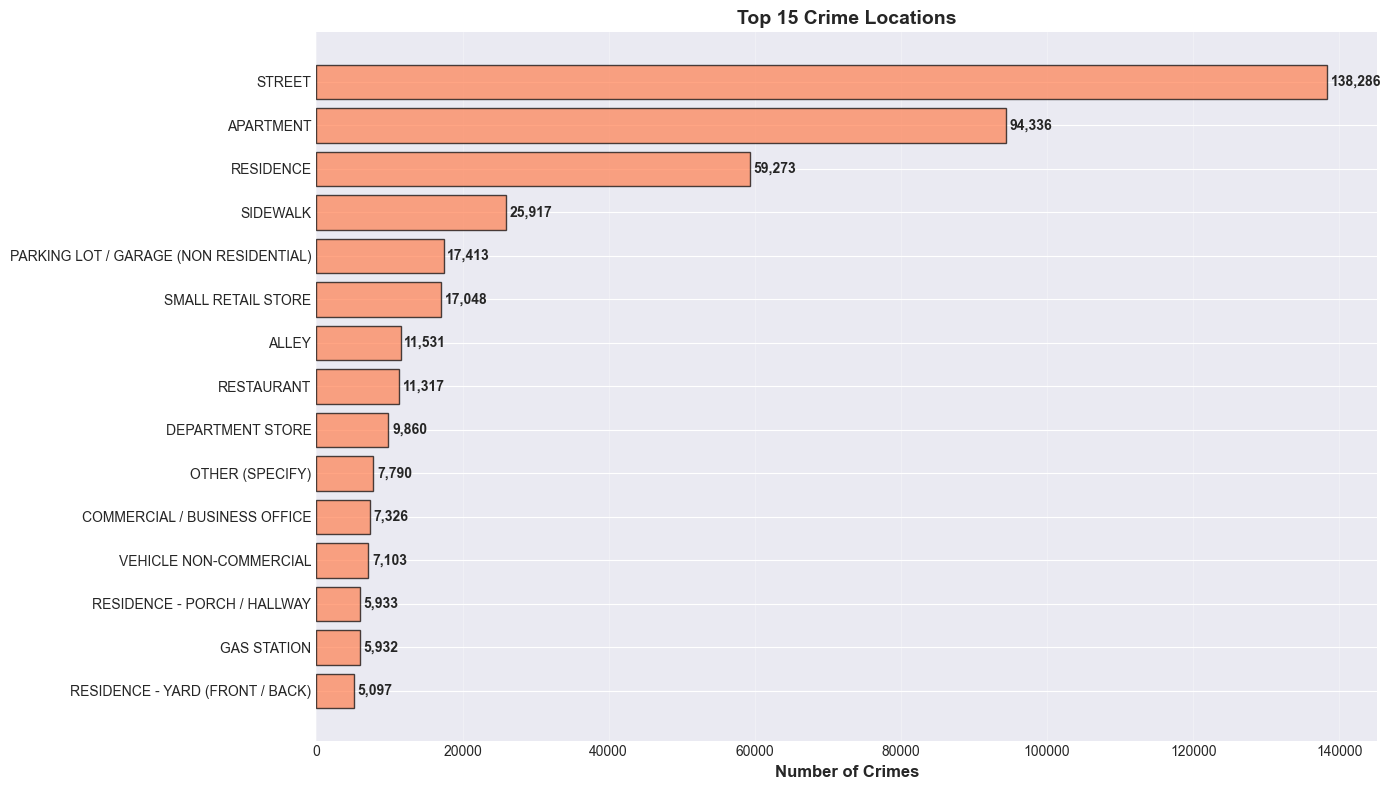

In [19]:
# Visualize top locations
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(range(len(location_crimes)), location_crimes.values, color='coral', alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(location_crimes)))
ax.set_yticklabels(location_crimes.index)
ax.set_xlabel('Number of Crimes', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Crime Locations', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(location_crimes.values):
    ax.text(v + 500, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

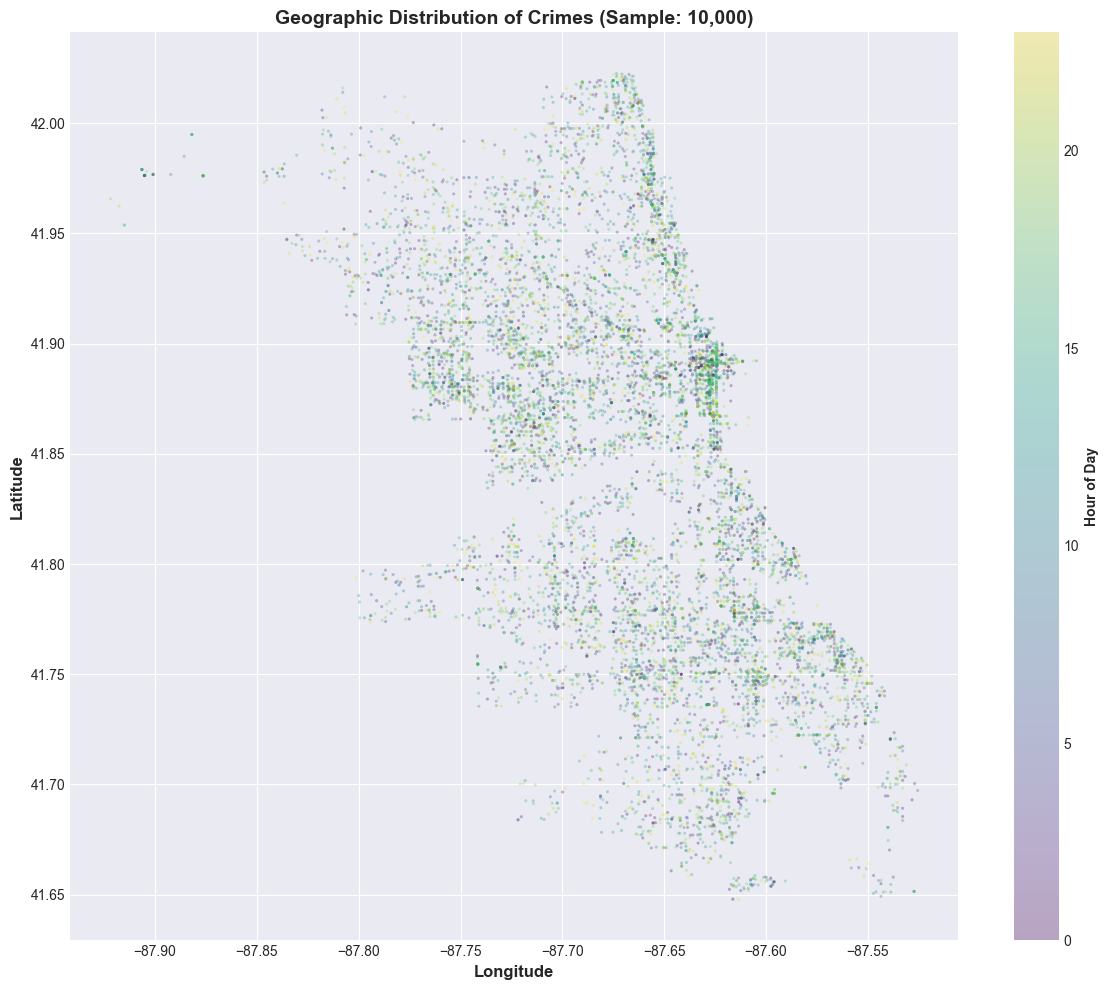


✓ Plotted 10,000 random crime locations
  Latitude range: 41.6446 to 42.0225
  Longitude range: -87.9397 to -87.5245


In [ ]:
# Sample for visualization 
sample_size = 10000
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(df_sample['Longitude'], df_sample['Latitude'], 
                     c=df_sample['Hour'], cmap='viridis', 
                     alpha=0.3, s=5, edgecolors='none')

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title(f'Geographic Distribution of Crimes (Sample: {sample_size:,})', 
             fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hour of Day', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Plotted {sample_size:,} random crime locations")
print(f"  Latitude range: {df['Latitude'].min():.4f} to {df['Latitude'].max():.4f}")
print(f"  Longitude range: {df['Longitude'].min():.4f} to {df['Longitude'].max():.4f}")

In [21]:
# Arrest statistics
arrest_stats = df['Arrest'].value_counts()
arrest_rate = (arrest_stats[True] / len(df) * 100)

print("="*70)
print("ARREST STATISTICS")
print("="*70)
print(f"Total Arrests: {arrest_stats[True]:,}")
print(f"No Arrests: {arrest_stats[False]:,}")
print(f"Arrest Rate: {arrest_rate:.2f}%")

# Domestic violence statistics
domestic_stats = df['Domestic'].value_counts()
domestic_rate = (domestic_stats[True] / len(df) * 100)

print("\n" + "="*70)
print("DOMESTIC VIOLENCE STATISTICS")
print("="*70)
print(f"Domestic Crimes: {domestic_stats[True]:,}")
print(f"Non-Domestic Crimes: {domestic_stats[False]:,}")
print(f"Domestic Crime Rate: {domestic_rate:.2f}%")

ARREST STATISTICS
Total Arrests: 67,017
No Arrests: 429,273
Arrest Rate: 13.50%

DOMESTIC VIOLENCE STATISTICS
Domestic Crimes: 90,481
Non-Domestic Crimes: 405,809
Domestic Crime Rate: 18.23%


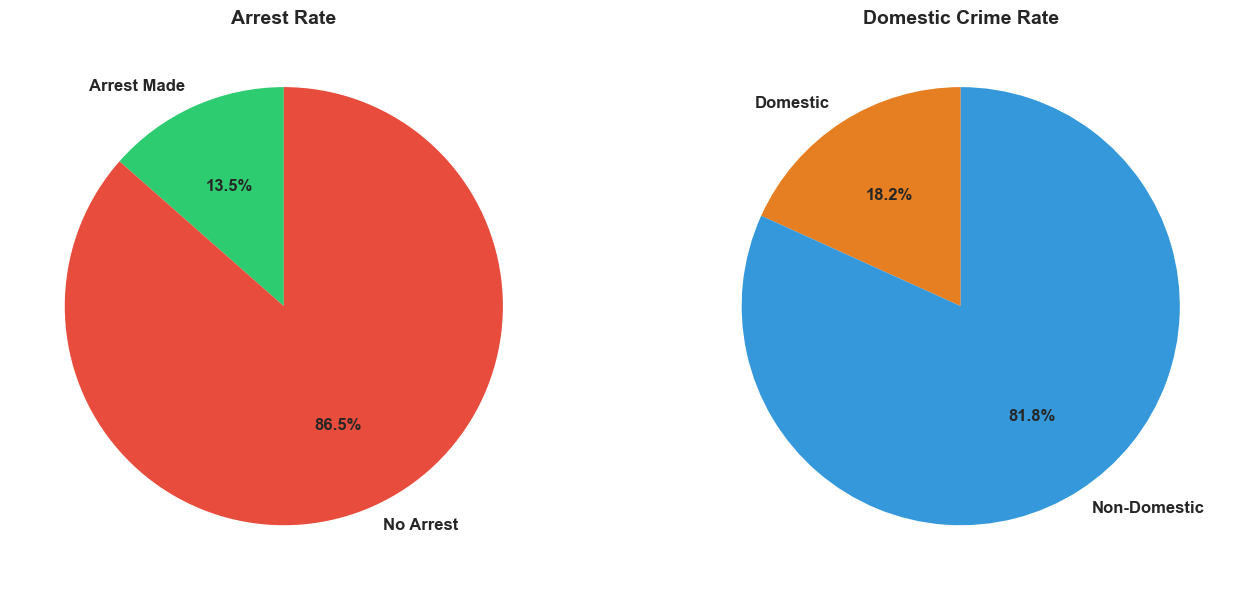

In [22]:
# Visualize arrest and domestic rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Arrest pie chart
arrest_labels = ['Arrest Made', 'No Arrest']
arrest_values = [arrest_stats[True], arrest_stats[False]]
ax1.pie(arrest_values, labels=arrest_labels, autopct='%1.1f%%', 
        colors=['#2ecc71', '#e74c3c'], startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Arrest Rate', fontsize=14, fontweight='bold')

# Domestic pie chart
domestic_labels = ['Domestic', 'Non-Domestic']
domestic_values = [domestic_stats[True], domestic_stats[False]]
ax2.pie(domestic_values, labels=domestic_labels, autopct='%1.1f%%',
        colors=['#e67e22', '#3498db'], startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Domestic Crime Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Calculate arrest rate by crime type
arrest_by_crime = df.groupby('Primary Type')['Arrest'].agg(['sum', 'count'])
arrest_by_crime['arrest_rate'] = (arrest_by_crime['sum'] / arrest_by_crime['count'] * 100).round(2)
arrest_by_crime = arrest_by_crime.sort_values('arrest_rate', ascending=False)

print("="*70)
print("ARREST RATE BY CRIME TYPE (Top 15)")
print("="*70)
print("\nHighest Arrest Rates:")
for crime, row in arrest_by_crime.head(15).iterrows():
    print(f"  {crime:30s} - {row['arrest_rate']:5.2f}% ({int(row['sum']):,}/{int(row['count']):,})")

ARREST RATE BY CRIME TYPE (Top 15)

Highest Arrest Rates:
  GAMBLING                       - 100.00% (35/35)
  CONCEALED CARRY LICENSE VIOLATION - 97.85% (409/418)
  NARCOTICS                      - 96.59% (11,090/11,481)
  LIQUOR LAW VIOLATION           - 96.49% (357/370)
  PROSTITUTION                   - 94.29% (429/455)
  PUBLIC INDECENCY               - 89.47% (17/19)
  INTERFERENCE WITH PUBLIC OFFICER - 88.14% (1,152/1,307)
  WEAPONS VIOLATION              - 60.78% (9,289/15,283)
  PUBLIC PEACE VIOLATION         - 48.11% (878/1,825)
  OBSCENITY                      - 47.96% (47/98)
  HOMICIDE                       - 39.54% (465/1,176)
  NON-CRIMINAL                   - 37.50% (3/8)
  OTHER NARCOTIC VIOLATION       - 37.50% (3/8)
  CRIMINAL TRESPASS              - 28.78% (2,681/9,316)
  OTHER OFFENSE                  - 18.67% (5,953/31,881)


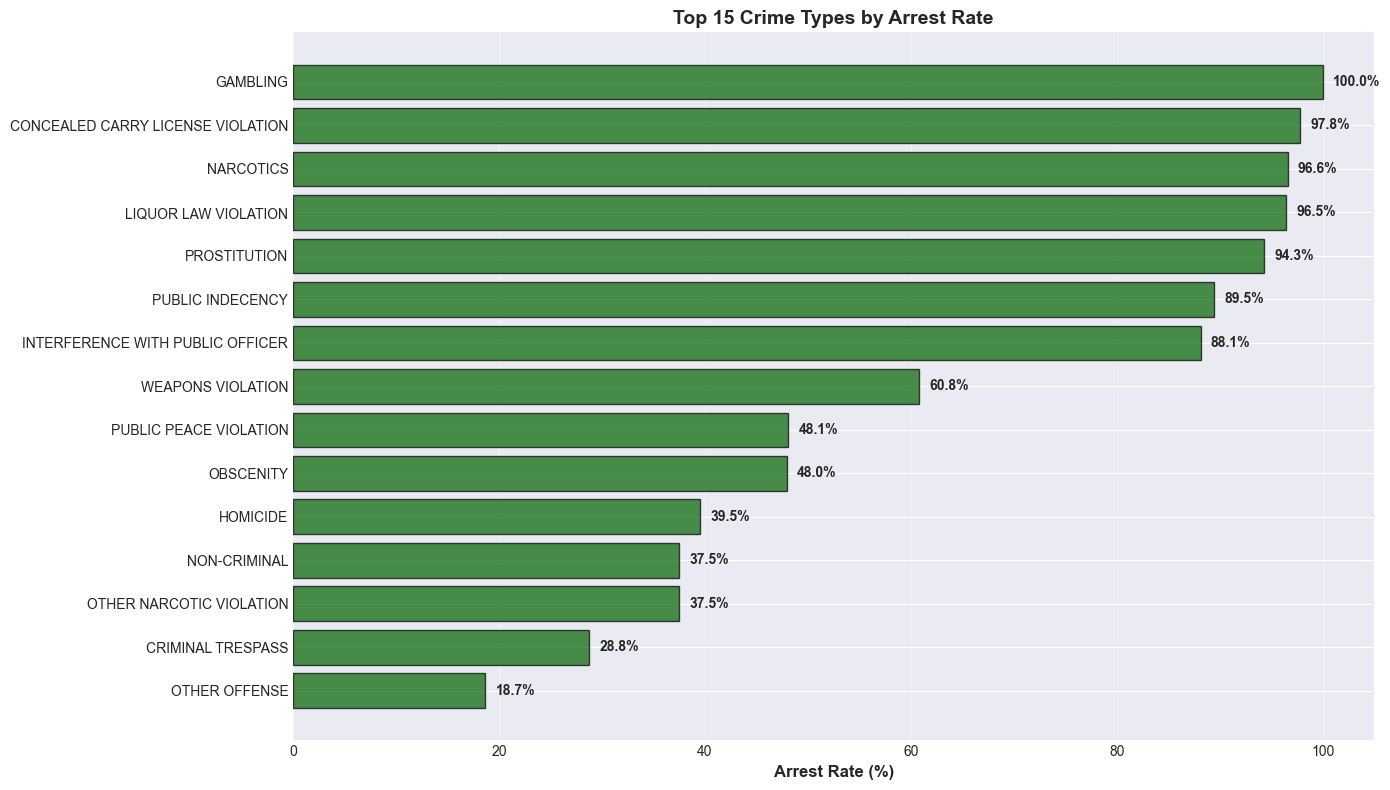

In [24]:
# Visualize arrest rates by crime type (top 15)
top15_arrest = arrest_by_crime.head(15)

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(range(len(top15_arrest)), top15_arrest['arrest_rate'].values, 
               color='darkgreen', alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(top15_arrest)))
ax.set_yticklabels(top15_arrest.index)
ax.set_xlabel('Arrest Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Crime Types by Arrest Rate', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top15_arrest['arrest_rate'].values):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# Domestic crime rate by type
domestic_by_crime = df.groupby('Primary Type')['Domestic'].agg(['sum', 'count'])
domestic_by_crime['domestic_rate'] = (domestic_by_crime['sum'] / domestic_by_crime['count'] * 100).round(2)
domestic_by_crime = domestic_by_crime.sort_values('domestic_rate', ascending=False)

print("="*70)
print("DOMESTIC VIOLENCE RATE BY CRIME TYPE (Top 10)")
print("="*70)
for crime, row in domestic_by_crime.head(10).iterrows():
    print(f"  {crime:30s} - {row['domestic_rate']:5.2f}% ({int(row['sum']):,}/{int(row['count']):,})")

DOMESTIC VIOLENCE RATE BY CRIME TYPE (Top 10)
  OFFENSE INVOLVING CHILDREN     - 77.55% (2,429/3,132)
  BATTERY                        - 53.47% (46,420/86,813)
  STALKING                       - 48.55% (486/1,001)
  OTHER OFFENSE                  - 35.96% (11,465/31,881)
  KIDNAPPING                     - 35.68% (81/227)
  ASSAULT                        - 28.30% (12,528/44,272)
  OBSCENITY                      - 24.49% (24/98)
  SEX OFFENSE                    - 21.10% (521/2,469)
  CRIMINAL SEXUAL ASSAULT        - 20.21% (625/3,092)
  HUMAN TRAFFICKING              - 14.81% (4/27)


In [26]:
# Cross-tabulation: Arrest vs Domestic
crosstab = pd.crosstab(df['Domestic'], df['Arrest'], normalize='index') * 100

print("="*70)
print("ARREST RATE: DOMESTIC vs NON-DOMESTIC")
print("="*70)
print(crosstab.round(2))

print(f"\nDomestic crimes arrest rate: {crosstab.loc[True, True]:.2f}%")
print(f"Non-domestic crimes arrest rate: {crosstab.loc[False, True]:.2f}%")

ARREST RATE: DOMESTIC vs NON-DOMESTIC
Arrest    False  True 
Domestic              
False     86.73  13.27
True      85.43  14.57

Domestic crimes arrest rate: 14.57%
Non-domestic crimes arrest rate: 13.27%


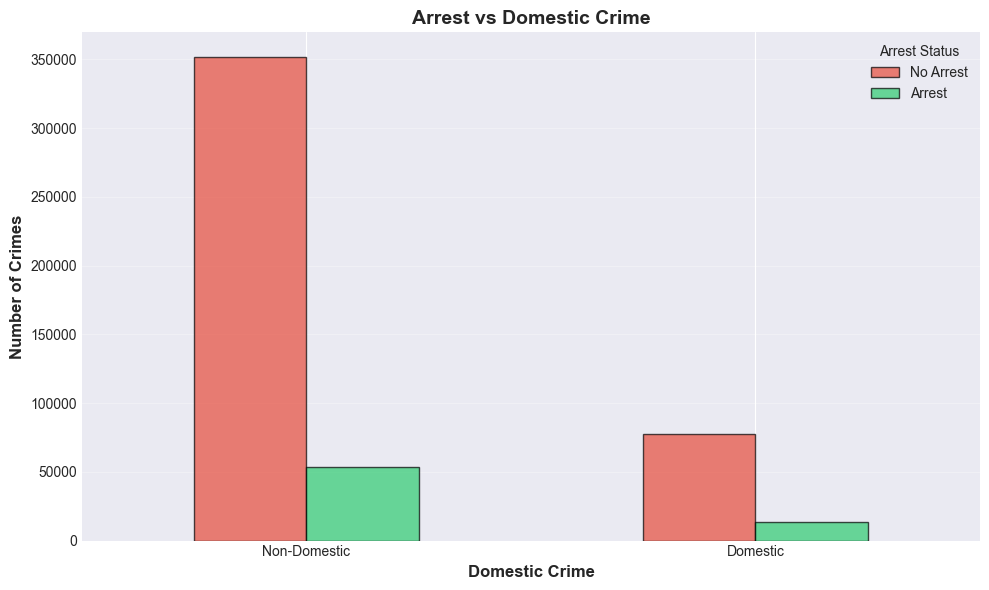

In [27]:
# Visualize relationship
arrest_domestic = df.groupby(['Domestic', 'Arrest']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))

arrest_domestic.plot(kind='bar', stacked=False, ax=ax, 
                     color=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')

ax.set_xlabel('Domestic Crime', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
ax.set_title('Arrest vs Domestic Crime', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Non-Domestic', 'Domestic'], rotation=0)
ax.legend(['No Arrest', 'Arrest'], title='Arrest Status')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("="*70)
print("EDA SUMMARY")
print("="*70)

print("\n DATASET OVERVIEW:")
print(f"  Total Records: {len(df):,}")
print(f"  Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Duration: {(df['Date'].max() - df['Date'].min()).days} days")

print("\n CRIME PATTERNS:")
print(f"  Total Crime Types: {df['Primary Type'].nunique()}")
print(f"  Most Common: {crime_counts.index[0]} ({crime_counts.values[0]:,})")
print(f"  Least Common: {crime_counts.index[-1]} ({crime_counts.values[-1]:,})")

print("\n TEMPORAL INSIGHTS:")
print(f"  Peak Month: {month_names[monthly_crimes.idxmax()-1]} ({monthly_crimes.max():,})")
print(f"  Peak Day: {day_crimes.idxmax()} ({day_crimes.max():,})")
print(f"  Peak Hour: {hourly_crimes.idxmax()}:00 ({hourly_crimes.max():,})")
print(f"  Quietest Hour: {hourly_crimes.idxmin()}:00 ({hourly_crimes.min():,})")

print("\n GEOGRAPHIC INSIGHTS:")
print(f"  Districts Covered: {df['District'].nunique()}")
print(f"  Highest Crime District: {district_crimes.idxmax()} ({district_crimes.max():,})")
print(f"  Most Common Location: {location_crimes.index[0]} ({location_crimes.values[0]:,})")

print("\n ARREST & DOMESTIC VIOLENCE:")
print(f"  Overall Arrest Rate: {arrest_rate:.2f}%")
print(f"  Domestic Crime Rate: {domestic_rate:.2f}%")
print(f"  Highest Arrest Crime: {arrest_by_crime.index[0]} ({arrest_by_crime.iloc[0]['arrest_rate']:.2f}%)")
print(f"  Domestic Arrest Rate: {crosstab.loc[True, True]:.2f}%")
print(f"  Non-Domestic Arrest Rate: {crosstab.loc[False, True]:.2f}%")

print("\n" + "="*70)
print("="*70)

COMPREHENSIVE EDA SUMMARY REPORT

📊 DATASET OVERVIEW:
  Total Records: 496,290
  Date Range: 2023-04-09 to 2025-03-15
  Duration: 706 days

🚨 CRIME PATTERNS:
  Total Crime Types: 31
  Most Common: THEFT (113,837)
  Least Common: OTHER NARCOTIC VIOLATION (8)

📅 TEMPORAL INSIGHTS:
  Peak Month: Jul (48,005)
  Peak Day: Friday (72,848)
  Peak Hour: 0:00 (34,532)
  Quietest Hour: 5:00 (9,174)

🗺️ GEOGRAPHIC INSIGHTS:
  Districts Covered: 23
  Highest Crime District: 8 (32,654)
  Most Common Location: STREET (138,286)

⚖️ ARREST & DOMESTIC VIOLENCE:
  Overall Arrest Rate: 13.50%
  Domestic Crime Rate: 18.23%
  Highest Arrest Crime: GAMBLING (100.00%)
  Domestic Arrest Rate: 14.57%
  Non-Domestic Arrest Rate: 13.27%

✅ EDA COMPLETE - Ready for Feature Engineering!
